# 📡 CSI-Based Indoor Localization — MIMO Router Classification (Final)
## 16 Positions | 4×4 Grid | ASUS RT-AC86U (bcm4366c0)

**Three toggles in the Config cell control everything:**

| Toggle | Options | Effect |
|---|---|---|
| `FEATURE_TYPE` | `'raw'` / `'stats'` | 63 raw amp² per core vs 2 stats (mean+std) per core |
| `ENABLE_MRC` | `True` / `False` | Include/exclude MRC strategy |
| `ENABLE_RF` | `True` / `False` | Include/exclude RF alongside ANN |

**Feature counts by FEATURE_TYPE:**

| FEATURE_TYPE | 1-Ant | MRC | 4-Ant |
|---|---|---|---|
| `'raw'` | 63 | 63 | 252 |
| `'stats'` | 2 | 2 | 8 |

**Note:** `'stats'` mode uses only `mean` and `std` across the 63 valid subcarriers per core.  
Amplitude squared **after** windowed averaging — consistent with original classification notebook.

## Step 1: Configuration — All Toggles Here

In [26]:
import os, sys

# ── Directory paths ────────────────────────────────────────────────────────────
PARSER_DIR   = os.path.expanduser('~/parser_check')               # nexmon_csi.py location
CAPTURES_DIR = os.path.expanduser('~/captures/16pos_experiment')  # pcap files
DATA_DIR     = os.path.expanduser('~/data')                       # CSV cache
OUTPUT_DIR   = os.path.expanduser('~/localization')               # saved plots

# ── ESP32-C5 transmitter MAC ───────────────────────────────────────────────────
# Only WiFi frames from this device are kept — all others discarded
ESP32_MAC    = 'd0:cf:13:e2:88:94'

# ── Windowing ──────────────────────────────────────────────────────────────────
# WINDOW=1  → no averaging, each raw frame is one sample (most data, noisier)
# WINDOW=5  → every 5 frames averaged into 1 sample (less data, smoother)
# Experiment showed WINDOW=1 gives best accuracy for this dataset
WINDOW       = 1

# ── Hardware constants ─────────────────────────────────────────────────────────
N_CORES = 4    # C15 bitmask = binary 1111 = all 4 antenna cores
N_SUB   = 64   # 40MHz → 512 bytes payload / 8 bytes per complex = 64 subcarriers

# ── Subcarrier cleaning ────────────────────────────────────────────────────────
# Index 63: DC artifact spike identified from diagnostic plot
# All other 63 subcarriers retained as valid
# To use all 64: set REMOVE_SUBS = [] and for other option use [63]
REMOVE_SUBS  = [0, 1, 63]
VALID_SUBS   = [i for i in range(N_SUB) if i not in REMOVE_SUBS]
N_VALID_SUBS = len(VALID_SUBS)   # = 63

# ==============================================================================
# ── THREE MAIN TOGGLES — change only these to switch experiments ───────────────
# ==============================================================================

FEATURE_TYPE = 'raw'
# 'raw'   → 63 raw amplitude² values per core
#            1-Ant=63, MRC=63, 4-Ant=252 features
# 'stats' → 2 statistical features per core (mean, std across 63 subcarriers)
#            1-Ant=2,  MRC=2,  4-Ant=8  features

ENABLE_MRC = False
# True  → include MRC strategy (sum amp² across all 4 cores, then extract features)
# False → only 1-Ant and 4-Ant strategies

ENABLE_RF = False
# True  → train RandomForestClassifier alongside ANN
# False → ANN only

# ==============================================================================

os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"PARSER_DIR   : {PARSER_DIR}")
print(f"CAPTURES_DIR : {CAPTURES_DIR}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"OUTPUT_DIR   : {OUTPUT_DIR}")
print(f"WINDOW       : {WINDOW}")
print(f"N_VALID_SUBS : {N_VALID_SUBS}  (removed: {REMOVE_SUBS})")
print(f"FEATURE_TYPE : {FEATURE_TYPE}")
print(f"ENABLE_MRC   : {ENABLE_MRC}")
print(f"ENABLE_RF    : {ENABLE_RF}")

PARSER_DIR   : /home/azbil-new/parser_check
CAPTURES_DIR : /home/azbil-new/captures/16pos_experiment
DATA_DIR     : /home/azbil-new/data
OUTPUT_DIR   : /home/azbil-new/localization
WINDOW       : 1
N_VALID_SUBS : 61  (removed: [0, 1, 63])
FEATURE_TYPE : raw
ENABLE_MRC   : False
ENABLE_RF    : False


## Step 2: Import Libraries

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Inline plots in Jupyter
%matplotlib inline

from collections             import defaultdict
from sklearn.neural_network  import MLPClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import accuracy_score, classification_report, confusion_matrix

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 3: Position Labels and Grid Map

Maps each `posN` label to:
- An integer class index (0–15) for the classifier
- A `(row, col)` cell in the 4×4 accuracy grid plot

**Arena layout (metres):**
```
col:    x=0.00   x=1.43   x=2.86   x=4.29
        ──────   ──────   ──────   ──────
y=4.29   pos4     pos8    pos12    pos16
y=2.86   pos3     pos7    pos11    pos15
y=1.43   pos2     pos6    pos10    pos14
y=0.00   pos1     pos5     pos9    pos13
```
`imshow` origin is top-left, so row 0 = top = y=4.29, row 3 = bottom = y=0.00.

In [28]:
# 16 position labels matching pcap filenames: pos1_4ant.pcap ... pos16_4ant.pcap
POS_LABELS = [f'pos{i}' for i in range(1, 17)]

# Integer class index: pos1→0, pos2→1, ..., pos16→15
POS_MAP = {p: i for i, p in enumerate(POS_LABELS)}

# (row, col) in 4×4 imshow grid
# row 0=top(y=4.29) ... row 3=bottom(y=0.00)
# col 0=left(x=0.00) ... col 3=right(x=4.29)
POS_GRID = {
    'pos1':  (3, 0), 'pos2':  (2, 0), 'pos3':  (1, 0), 'pos4':  (0, 0),
    'pos5':  (3, 1), 'pos6':  (2, 1), 'pos7':  (1, 1), 'pos8':  (0, 1),
    'pos9':  (3, 2), 'pos10': (2, 2), 'pos11': (1, 2), 'pos12': (0, 2),
    'pos13': (3, 3), 'pos14': (2, 3), 'pos15': (1, 3), 'pos16': (0, 3),
}

print("Position labels:", POS_LABELS)
print("\nPOS_MAP (label → class index):")
for k, v in POS_MAP.items():
    print(f"  {k} → {v}")

Position labels: ['pos1', 'pos2', 'pos3', 'pos4', 'pos5', 'pos6', 'pos7', 'pos8', 'pos9', 'pos10', 'pos11', 'pos12', 'pos13', 'pos14', 'pos15', 'pos16']

POS_MAP (label → class index):
  pos1 → 0
  pos2 → 1
  pos3 → 2
  pos4 → 3
  pos5 → 4
  pos6 → 5
  pos7 → 6
  pos8 → 7
  pos9 → 8
  pos10 → 9
  pos11 → 10
  pos12 → 11
  pos13 → 12
  pos14 → 13
  pos15 → 14
  pos16 → 15


## Step 4: Parse PCAP Files

**What this does step by step:**

1. Loads `pos1_4ant.pcap` through `pos16_4ant.pcap`
2. Filters to ESP32-C5 MAC only — discards all other WiFi transmitters
3. Separates frames by `core_id` (0=antenna0, 1=antenna1, 2=antenna2, 3=antenna3)
4. Windowed averaging: every WINDOW consecutive frames → 1 averaged sample
5. Computes `amplitude² = |H[k]|²` per subcarrier per core per window
6. Removes artifact subcarrier (index 63) identified from diagnostic plot
7. Returns one DataFrame with all positions, all cores, all windows

**Column naming:** `amp_sq_c{core}_s{subcarrier}`  
Example: `amp_sq_c2_s015` = amplitude² of antenna core 2, subcarrier index 15

**CSV caching:** After first parse, results saved to CSV. Subsequent runs load instantly.

In [29]:
CSV_4ANT = os.path.join(DATA_DIR, 'csi_16pos_4ant_40mhz_cleaned.csv')


def parse_16pos(n_cores):
    """Parse all 16 position pcap files. Returns DataFrame with amplitude² features."""
    sys.path.insert(0, PARSER_DIR)
    from nexmon_csi import parse_pcap, filter_mac

    all_dfs = []

    for pos in POS_LABELS:
        fname = f"{pos}_4ant.pcap"
        fpath = os.path.join(CAPTURES_DIR, fname)
        print(f"  Parsing {fname} ...", end=' ')

        frames = parse_pcap(fpath, verbose=False)
        frames = filter_mac(frames, ESP32_MAC)

        if len(frames) == 0:
            print(f"WARNING: No frames found — skipping")
            continue

        # Separate by antenna core
        cores = defaultdict(list)
        for f in frames:
            cores[f.core_id].append(f)

        core0_frames = cores[0]
        n_frames     = len(core0_frames)
        n_windows    = n_frames // WINDOW

        if n_windows == 0:
            print(f"WARNING: Too few frames ({n_frames}). Skipping.")
            continue

        # Compute amplitude² per core
        core_amp_sq = {}
        for cid in range(n_cores):
            if cid not in cores:
                continue
            cf = cores[cid][:n_windows * WINDOW]

            # |H[k]| = sqrt(I[k]² + Q[k]²) for each subcarrier k
            amp_raw = np.array([np.abs(f.csi) for f in cf])  # (n*WINDOW, 64)

            # Remove artifact subcarrier(s)
            amp_raw = amp_raw[:, VALID_SUBS]                  # (n*WINDOW, 63)

            # Window averaging: reshape → mean over WINDOW axis
            amp_avg = amp_raw.reshape(n_windows, WINDOW, N_VALID_SUBS).mean(axis=1)  # (n, 63)

            # Square → power
            core_amp_sq[cid] = amp_avg ** 2

        # Build DataFrame: join all cores side by side
        df_parts = []
        for cid in range(n_cores):
            if cid not in core_amp_sq:
                continue
            cols = [f'amp_sq_c{cid}_s{i:03d}' for i in VALID_SUBS]
            df_parts.append(pd.DataFrame(core_amp_sq[cid], columns=cols))

        df_tmp = pd.concat(df_parts, axis=1)

        # Add metadata
        mid_frames = [core0_frames[i * WINDOW + WINDOW // 2] for i in range(n_windows)]
        df_tmp.insert(0, 'position',  pos)
        df_tmp.insert(1, 'frame_idx', np.arange(len(df_tmp)))
        df_tmp.insert(2, 'timestamp', [f.ts   for f in mid_frames])
        df_tmp.insert(3, 'rssi_dbm',  [f.rssi for f in mid_frames])

        all_dfs.append(df_tmp)
        print(f"{n_frames} frames | {n_windows} windows | {len(df_parts)} cores")

    return pd.concat(all_dfs, ignore_index=True)


# Load from cache or parse fresh
if os.path.exists(CSV_4ANT):
    print(f"Loading cached CSV: {CSV_4ANT}")
    df_4ant = pd.read_csv(CSV_4ANT)
else:
    print("Parsing pcap files (first run — will be cached after)...")
    df_4ant = parse_16pos(n_cores=4)
    df_4ant.to_csv(CSV_4ANT, index=False)
    print(f"\nSaved → {CSV_4ANT}")

print(f"\nDataset shape : {df_4ant.shape}")
print(f"Columns (first 10): {list(df_4ant.columns[:10])}")
print(f"Positions: {df_4ant['position'].unique()}")
display(df_4ant.head(3))

Parsing pcap files (first run — will be cached after)...
  Parsing pos1_4ant.pcap ... 3286 frames | 3286 windows | 4 cores
  Parsing pos2_4ant.pcap ... 3515 frames | 3515 windows | 4 cores
  Parsing pos3_4ant.pcap ... 3570 frames | 3570 windows | 4 cores
  Parsing pos4_4ant.pcap ... 3592 frames | 3592 windows | 4 cores
  Parsing pos5_4ant.pcap ... 3582 frames | 3582 windows | 4 cores
  Parsing pos6_4ant.pcap ... 3582 frames | 3582 windows | 4 cores
  Parsing pos7_4ant.pcap ... 3574 frames | 3574 windows | 4 cores
  Parsing pos8_4ant.pcap ... 3566 frames | 3566 windows | 4 cores
  Parsing pos9_4ant.pcap ... 3566 frames | 3566 windows | 4 cores
  Parsing pos10_4ant.pcap ... 3605 frames | 3605 windows | 4 cores
  Parsing pos11_4ant.pcap ... 3586 frames | 3586 windows | 4 cores
  Parsing pos12_4ant.pcap ... 3547 frames | 3547 windows | 4 cores
  Parsing pos13_4ant.pcap ... 3598 frames | 3598 windows | 4 cores
  Parsing pos14_4ant.pcap ... 3602 frames | 3602 windows | 4 cores
  Parsing pos1

,position,frame_idx,timestamp,rssi_dbm,amp_sq_c0_s002,amp_sq_c0_s003,amp_sq_c0_s004,amp_sq_c0_s005,amp_sq_c0_s006,amp_sq_c0_s007,...,amp_sq_c3_s053,amp_sq_c3_s054,amp_sq_c3_s055,amp_sq_c3_s056,amp_sq_c3_s057,amp_sq_c3_s058,amp_sq_c3_s059,amp_sq_c3_s060,amp_sq_c3_s061,amp_sq_c3_s062
0,pos1,0,1.782309e+09,-52,1737837.75,404814.062500,4.044960e+05,1.438352e-04,0.052695,258318.1250,...,672.840881,8.734981e+05,4.112720e+05,4.279120e+05,980375.062500,0.631901,4.103694e-02,7.784765e-07,1.040910e+06,9.698947e-04
1,pos1,1,1.782309e+09,-51,719346.25,0.000241,7.509974e-07,7.357739e-07,0.052892,3220.5625,...,0.000006,2.026354e-08,8.074129e-08,1.257053e-04,0.000001,597.661316,8.371861e+05,5.746000e+05,1.113893e+05,2.080800e+06
2,pos1,2,1.782309e+09,-52,257556.25,258318.062500,2.423101e+05,2.137193e+00,0.052667,608790.0625,...,0.000021,1.011533e+06,1.660880e+05,8.937276e-07,808.691406,193689.062500,4.606628e-07,3.517876e-01,2.437891e+05,2.016534e+06


## Step 5: Feature Extraction

Controlled by `FEATURE_TYPE` toggle in Config:

- **`'raw'`** → 63 raw amplitude² values per core directly (1-Ant=63, MRC=63, 4-Ant=252)
- **`'stats'`** → 2 statistical features per core: **mean** and **std** across 63 subcarriers (1-Ant=2, MRC=2, 4-Ant=8)

Both versions cached separately — switching is instant after first run of each.

**MRC computation (both modes):**  
`MRC[k] = c0[k]² + c1[k]² + c2[k]² + c3[k]²` for each subcarrier k → sums power across all 4 antennas.

In [30]:
CSV_FEAT_RAW   = os.path.join(DATA_DIR, 'classification_16pos_features_raw.csv')
CSV_FEAT_STATS = os.path.join(DATA_DIR, 'classification_16pos_features_stats.csv')

# Metadata columns carried through from raw DataFrame
META_COLS = ['position', 'frame_idx', 'timestamp', 'rssi_dbm']


def build_raw_features(df_raw):
    """63 raw amp² values per core + 63 MRC values — vectorized."""
    feat_df  = df_raw[META_COLS].copy().reset_index(drop=True)
    mrc_sum  = np.zeros((len(df_raw), N_VALID_SUBS))

    for cid in range(N_CORES):
        cols = [c for c in df_raw.columns if c.startswith(f'amp_sq_c{cid}_')]
        if not cols:
            continue
        vals = df_raw[cols].values                            # (n_samples, 63)
        for j, col in enumerate(cols):
            feat_df[f'raw_c{cid}_s{j:03d}'] = vals[:, j]    # raw amp² per subcarrier
        mrc_sum += vals                                       # accumulate MRC sum

    # MRC: sum of amp² across all 4 cores per subcarrier
    for j in range(N_VALID_SUBS):
        feat_df[f'raw_mrc_s{j:03d}'] = mrc_sum[:, j]

    return feat_df


def build_stats_features(df_raw):
    """2 statistical features per core: mean and std across 63 subcarriers."""
    feat_df = df_raw[META_COLS].copy().reset_index(drop=True)
    mrc_sum = np.zeros((len(df_raw), N_VALID_SUBS))

    for cid in range(N_CORES):
        cols = [c for c in df_raw.columns if c.startswith(f'amp_sq_c{cid}_')]
        if not cols:
            continue
        vals = df_raw[cols].values                            # (n_samples, 63)
        feat_df[f'c{cid}_mean'] = vals.mean(axis=1)          # mean across subcarriers
        feat_df[f'c{cid}_std']  = vals.std(axis=1)           # std across subcarriers
        mrc_sum += vals

    # MRC stats: mean and std of the summed power across subcarriers
    feat_df['mrc_mean'] = mrc_sum.mean(axis=1)
    feat_df['mrc_std']  = mrc_sum.std(axis=1)

    return feat_df


# ── Load or build based on FEATURE_TYPE ───────────────────────────────────────
if FEATURE_TYPE == 'raw':
    if os.path.exists(CSV_FEAT_RAW):
        print(f"Loading cached raw features: {CSV_FEAT_RAW}")
        feat_df = pd.read_csv(CSV_FEAT_RAW)
    else:
        print("Building raw subcarrier features...")
        feat_df = build_raw_features(df_4ant)
        feat_df.to_csv(CSV_FEAT_RAW, index=False)
        print(f"Saved → {CSV_FEAT_RAW}")
    FEAT_1ANT = [c for c in feat_df.columns if c.startswith('raw_c0_')]
    FEAT_MRC  = [c for c in feat_df.columns if c.startswith('raw_mrc_')]
    FEAT_4ANT = [c for c in feat_df.columns
                 if any(c.startswith(f'raw_c{cid}_') for cid in range(N_CORES))]

elif FEATURE_TYPE == 'stats':
    if os.path.exists(CSV_FEAT_STATS):
        print(f"Loading cached stats features: {CSV_FEAT_STATS}")
        feat_df = pd.read_csv(CSV_FEAT_STATS)
    else:
        print("Building mean+std features...")
        feat_df = build_stats_features(df_4ant)
        feat_df.to_csv(CSV_FEAT_STATS, index=False)
        print(f"Saved → {CSV_FEAT_STATS}")
    FEAT_1ANT = ['c0_mean', 'c0_std']
    FEAT_MRC  = ['mrc_mean', 'mrc_std']
    FEAT_4ANT = [f'c{cid}_{s}' for cid in range(N_CORES) for s in ['mean', 'std']]

else:
    raise ValueError(f"FEATURE_TYPE must be 'raw' or 'stats', got: {FEATURE_TYPE}")

assert len(FEAT_1ANT) > 0, "FEAT_1ANT empty — check column names"
assert len(FEAT_MRC)  > 0, "FEAT_MRC empty — check column names"
assert len(FEAT_4ANT) > 0, "FEAT_4ANT empty — check column names"

print(f"\nFEATURE_TYPE : {FEATURE_TYPE}")
print(f"1-Ant  : {len(FEAT_1ANT):3d} features  {FEAT_1ANT[:4]}")
print(f"MRC    : {len(FEAT_MRC):3d} features  {FEAT_MRC[:4]}")
print(f"4-Ant  : {len(FEAT_4ANT):3d} features")
display(feat_df.head(3))

Building raw subcarrier features...
Saved → /home/azbil-new/data/classification_16pos_features_raw.csv

FEATURE_TYPE : raw
1-Ant  :  61 features  ['raw_c0_s000', 'raw_c0_s001', 'raw_c0_s002', 'raw_c0_s003']
MRC    :  61 features  ['raw_mrc_s000', 'raw_mrc_s001', 'raw_mrc_s002', 'raw_mrc_s003']
4-Ant  : 244 features


,position,frame_idx,timestamp,rssi_dbm,raw_c0_s000,raw_c0_s001,raw_c0_s002,raw_c0_s003,raw_c0_s004,raw_c0_s005,...,raw_mrc_s051,raw_mrc_s052,raw_mrc_s053,raw_mrc_s054,raw_mrc_s055,raw_mrc_s056,raw_mrc_s057,raw_mrc_s058,raw_mrc_s059,raw_mrc_s060
0,pos1,0,1.782309e+09,-52,1737837.75,404814.062500,4.044960e+05,1.438352e-04,0.052695,258318.1250,...,3.604681e+05,8.769626e+05,411272.590879,9.674443e+05,2.502804e+06,678821.264714,2.136958e+06,1.139738e+06,1.201248e+06,2.081310e+06
1,pos1,1,1.782309e+09,-51,719346.25,0.000241,7.509974e-07,7.357739e-07,0.052892,3220.5625,...,2.027843e+06,1.285980e+06,287746.798268,1.138362e+05,4.527434e+05,648221.598817,8.853861e+05,5.794070e+05,1.152966e+06,4.534724e+06
2,pos1,2,1.782309e+09,-52,257556.25,258318.062500,2.423101e+05,2.137193e+00,0.052667,608790.0625,...,7.752673e+05,1.788288e+06,636508.776679,1.313330e+06,4.486934e+05,364671.312501,2.589989e+06,2.642013e+06,1.790764e+06,2.441638e+06


## Step 6: Build Feature Matrices X and Label Vector y

- **X** = feature matrix (n_samples × n_features)
- **y** = integer class labels (0–15 mapping to pos1–pos16)

All three strategies built from the same `feat_df`.

In [31]:
def get_Xy(df, feature_cols):
    """Extract feature matrix X and integer label vector y from DataFrame."""
    Xs, ys = [], []
    for pos in POS_LABELS:
        sub = df[df['position'] == pos]
        Xs.append(sub[feature_cols].values)
        ys.append(np.full(len(sub), POS_MAP[pos]))
    return np.vstack(Xs), np.hstack(ys)


# Strategy 1: 1-Antenna — core 0 only
X_1ant, y_1ant = get_Xy(feat_df, FEAT_1ANT)
print(f"1-Ant  : X shape = {X_1ant.shape}  ({len(FEAT_1ANT)} features — core 0)")

# Strategy 2: MRC — features extracted from summed amp² across 4 cores
if ENABLE_MRC:
    X_mrc, y_mrc = get_Xy(feat_df, FEAT_MRC)
    print(f"MRC    : X shape = {X_mrc.shape}  ({len(FEAT_MRC)} features — MRC combined)")

# Strategy 3: 4-Antenna — all 4 cores concatenated
X_concat, y_concat = get_Xy(feat_df, FEAT_4ANT)
print(f"4-Ant  : X shape = {X_concat.shape}  ({len(FEAT_4ANT)} features — all cores)")

1-Ant  : X shape = (56936, 61)  (61 features — core 0)
4-Ant  : X shape = (56936, 244)  (244 features — all cores)


## Step 7: Train/Test Split and Feature Scaling

- **Split:** 80% train, 20% test — `stratify=y` ensures all 16 positions appear proportionally in both sets
- **Scaling (ANN only):** `StandardScaler` normalizes each feature to zero mean, unit variance  
  Formula: `x_scaled = (x - mean_train) / std_train`  
  Fitted on training data only — never on test data (prevents data leakage)
- **RF does NOT need scaling** — decision tree splits are scale-invariant, based on rank order not magnitude

In [32]:
def prepare_split(X, y, test_size=0.2):
    """Stratified split + StandardScaler for ANN. Returns scaled arrays + scaler."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42)
    sc = StandardScaler()
    return sc.fit_transform(X_tr), sc.transform(X_te), y_tr, y_te, sc


# ── ANN splits (scaled) ────────────────────────────────────────────────────────
X_tr_1ant,   X_te_1ant,   y_tr_1ant,   y_te_1ant,   sc_1ant   = prepare_split(X_1ant,   y_1ant)
X_tr_concat, X_te_concat, y_tr_concat, y_te_concat, sc_concat = prepare_split(X_concat, y_concat)
if ENABLE_MRC:
    X_tr_mrc, X_te_mrc, y_tr_mrc, y_te_mrc, sc_mrc = prepare_split(X_mrc, y_mrc)

# ── RF splits (unscaled — same indices via same random_state) ──────────────────
X_tr_1ant_raw,   X_te_1ant_raw,   y_tr_1ant_raw,   y_te_1ant_raw   = train_test_split(
    X_1ant,   y_1ant,   test_size=0.2, stratify=y_1ant,   random_state=42)
X_tr_concat_raw, X_te_concat_raw, y_tr_concat_raw, y_te_concat_raw = train_test_split(
    X_concat, y_concat, test_size=0.2, stratify=y_concat, random_state=42)
if ENABLE_MRC:
    X_tr_mrc_raw, X_te_mrc_raw, y_tr_mrc_raw, y_te_mrc_raw = train_test_split(
        X_mrc, y_mrc, test_size=0.2, stratify=y_mrc, random_state=42)

print(f"1-Ant  → train: {len(X_tr_1ant):6d}  test: {len(X_te_1ant):6d}")
if ENABLE_MRC:
    print(f"MRC    → train: {len(X_tr_mrc):6d}  test: {len(X_te_mrc):6d}")
print(f"4-Ant  → train: {len(X_tr_concat):6d}  test: {len(X_te_concat):6d}")

1-Ant  → train:  45548  test:  11388
4-Ant  → train:  45548  test:  11388


## Step 8: Train ANN and Random Forest Classifiers

### ANN (MLPClassifier)
- **Architecture:** Input → hidden layers → 16 output neurons (one per position)
- **Activation:** ReLU — `max(0, x)`, avoids vanishing gradient, fast to compute
- **Optimizer:** Adam — adapts learning rate per weight, generally best default
- **Output:** Softmax probabilities across 16 classes, argmax = predicted position
- **Needs scaling** — large feature values dominate gradient updates without it

### RF (RandomForestClassifier)
- **200 decision trees**, each trained on a random subset of features and samples
- Each tree asks questions like: *"Is amp_sq_c2_s031 > 0.043? → likely pos7"*
- Final prediction = majority vote across all 200 trees
- **Does NOT need scaling** — splits based on rank order, not magnitude
- **n_jobs=-1** → trains all 200 trees in parallel using all CPU cores

> **Controlled by `ENABLE_RF` toggle** — set `False` to skip RF and run ANN only.

In [33]:
def train_ann(X_tr, y_tr, label, hidden=(128, 64)):
    """Train MLPClassifier. hidden tuple controls layer sizes."""
    ann = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42
    )
    ann.fit(X_tr, y_tr)
    print(f"  ANN {label:50s} → epochs: {ann.n_iter_:3d}  loss: {ann.loss_:.4f}")
    return ann


def train_rf(X_tr, y_tr, label, n_estimators=200):
    """Train RandomForestClassifier with parallel tree building."""
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1        # parallel training across all CPU cores
    )
    rf.fit(X_tr, y_tr)
    print(f"  RF  {label:50s} → {n_estimators} trees trained")
    return rf


print("[ ANN Training ]")
ann_1ant   = train_ann(X_tr_1ant,   y_tr_1ant,   f'1-Ant core0  ({len(FEAT_1ANT)} feat)',       (128, 64))
if ENABLE_MRC:
    ann_mrc = train_ann(X_tr_mrc,   y_tr_mrc,    f'MRC          ({len(FEAT_MRC)} feat)',         (128, 64))
ann_concat = train_ann(X_tr_concat, y_tr_concat, f'4-Ant MIMO   ({len(FEAT_4ANT)} feat)',        (256, 128, 64))

if ENABLE_RF:
    print("\n[ RF Training ]")
    rf_1ant   = train_rf(X_tr_1ant_raw,   y_tr_1ant_raw,   f'1-Ant core0  ({len(FEAT_1ANT)} feat)')
    if ENABLE_MRC:
        rf_mrc = train_rf(X_tr_mrc_raw,   y_tr_mrc_raw,    f'MRC          ({len(FEAT_MRC)} feat)')
    rf_concat = train_rf(X_tr_concat_raw, y_tr_concat_raw, f'4-Ant MIMO   ({len(FEAT_4ANT)} feat)')
else:
    print("\nRF skipped (ENABLE_RF=False)")

print("\nAll classifiers trained!")

[ ANN Training ]
  ANN 1-Ant core0  (61 feat)                             → epochs: 355  loss: 1.1800
  ANN 4-Ant MIMO   (244 feat)                            → epochs: 125  loss: 0.1119

RF skipped (ENABLE_RF=False)

All classifiers trained!


## Step 9: Evaluate on Test Set

Runs each trained model on the held-out 20% test set.  
Prints accuracy + per-position precision, recall, F1-score.

In [34]:
# Build results dicts: key=label → value=(accuracy%, y_test, y_pred, model)
results_ann = {}
results_rf  = {}

# ── Build experiment lists ─────────────────────────────────────────────────────
ann_exps = [
    ('1-Antenna — Core 0', ann_1ant,   X_te_1ant,   y_te_1ant),
    ('4-Antenna — MIMO',   ann_concat, X_te_concat, y_te_concat),
]
if ENABLE_RF:
    rf_exps = [
        ('1-Antenna — Core 0', rf_1ant,   X_te_1ant_raw,   y_te_1ant_raw),
        ('4-Antenna — MIMO',   rf_concat, X_te_concat_raw, y_te_concat_raw),
    ]

if ENABLE_MRC:
    ann_exps.insert(1, ('4-Antenna — MRC', ann_mrc, X_te_mrc, y_te_mrc))
    if ENABLE_RF:
        rf_exps.insert(1, ('4-Antenna — MRC', rf_mrc, X_te_mrc_raw, y_te_mrc_raw))

# ── ANN evaluation ────────────────────────────────────────────────────────────
print("=" * 65)
print("ANN RESULTS")
print("=" * 65)
for label, model, X_te, y_te in ann_exps:
    y_pred = model.predict(X_te)
    acc    = accuracy_score(y_te, y_pred) * 100
    results_ann[f'ANN — {label}'] = (acc, y_te, y_pred, model)
    print(f"\n{label}  →  Accuracy: {acc:.2f}%")
    print(classification_report(y_te, y_pred, target_names=POS_LABELS, zero_division=0))

# ── RF evaluation ─────────────────────────────────────────────────────────────
if ENABLE_RF:
    print("=" * 65)
    print("RF RESULTS")
    print("=" * 65)
    for label, model, X_te, y_te in rf_exps:
        y_pred = model.predict(X_te)
        acc    = accuracy_score(y_te, y_pred) * 100
        results_rf[f'RF  — {label}'] = (acc, y_te, y_pred, model)
        print(f"\n{label}  →  Accuracy: {acc:.2f}%")
        print(classification_report(y_te, y_pred, target_names=POS_LABELS, zero_division=0))
else:
    print("RF evaluation skipped (ENABLE_RF=False)")

ANN RESULTS

1-Antenna — Core 0  →  Accuracy: 39.66%
              precision    recall  f1-score   support

        pos1       0.53      0.55      0.54       657
        pos2       0.42      0.37      0.40       703
        pos3       0.47      0.51      0.49       714
        pos4       0.45      0.52      0.49       719
        pos5       0.22      0.12      0.16       716
        pos6       0.44      0.44      0.44       716
        pos7       0.38      0.32      0.35       715
        pos8       0.32      0.32      0.32       713
        pos9       0.63      0.65      0.64       713
       pos10       0.47      0.51      0.49       721
       pos11       0.25      0.31      0.28       717
       pos12       0.34      0.34      0.34       709
       pos13       0.37      0.45      0.41       720
       pos14       0.35      0.40      0.37       721
       pos15       0.27      0.25      0.26       718
       pos16       0.34      0.31      0.33       716

    accuracy               

## Step 10: 5-Fold Cross Validation

Instead of one train/test split, the data is split **5 times** — each time a different 20% is held out.  
Gives 5 accuracy scores. Mean ± Std tells you:
- **Mean** → reliable overall accuracy estimate
- **Std** → consistency. Small std (e.g. ±0.5%) = stable model. Large std (e.g. ±5%) = sensitive to data split.

**Note:** RF uses unscaled features in CV (same as training). ANN uses scaled features.

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Build CV experiment list ───────────────────────────────────────────────────
cv_experiments = [
    ('1-Ant core0', X_1ant,   y_1ant,   sc_1ant,   (128, 64)),
    ('4-Ant MIMO',  X_concat, y_concat, sc_concat, (256, 128, 64)),
]
if ENABLE_MRC:
    cv_experiments.insert(1, ('MRC', X_mrc, y_mrc, sc_mrc, (128, 64)))

print(f"{'Strategy':<20} {'ANN (5-fold)':>22}  {'RF (5-fold)':>22}")
print("-" * 70)

for label, X, y, sc, hidden in cv_experiments:
    X_s = sc.transform(X)   # scaled for ANN — scaler already fitted on train set

    ann_cv = MLPClassifier(hidden_layer_sizes=hidden,
                           activation='relu', solver='adam',
                           max_iter=500, random_state=42)
    ann_scores = cross_val_score(ann_cv, X_s, y, cv=cv)

    ann_str = f"{ann_scores.mean()*100:>7.1f}% ± {ann_scores.std()*100:.1f}%"

    if ENABLE_RF:
        rf_cv     = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        rf_scores = cross_val_score(rf_cv, X, y, cv=cv)   # unscaled for RF
        rf_str    = f"{rf_scores.mean()*100:>7.1f}% ± {rf_scores.std()*100:.1f}%"
    else:
        rf_str = "       N/A (skipped)"

    print(f"{label:<20} {ann_str:>22}  {rf_str:>22}")

Strategy                       ANN (5-fold)             RF (5-fold)
----------------------------------------------------------------------
1-Ant core0                    39.4% ± 0.3%           N/A (skipped)
4-Ant MIMO                     50.1% ± 0.3%           N/A (skipped)


## Step 11: Plots

### Plot 1 — Confusion Matrices (ANN and RF, if enabled)
16×16 matrix — rows = true position, columns = predicted position.  
**Diagonal** = correct predictions. **Off-diagonal** = errors (which positions get confused with which).

### Plot 2 — Per-Position Accuracy Grid (ANN and RF, if enabled)
4×4 grid matching your physical arena. Each cell = one position.  
**Color:** Red=low accuracy, Yellow=medium, Green=high.  
Reveals which positions each classifier handles well vs poorly.

### Plot 3 — ANN Training Loss Curves
Cross-entropy loss per epoch. Should decrease smoothly and flatten.

### Plot 4 — Amplitude² Profiles Per Core
Mean amplitude² vs subcarrier index, one line per position per antenna core.  
Well-separated lines = that core carries good location fingerprint.  
*(Only shown for `FEATURE_TYPE='raw'` — stats mode has no per-subcarrier profile.)*

In [36]:
sns.set_theme(style="white")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "text.color":       "black",
    "axes.labelcolor":  "black",
    "xtick.color":      "black",
    "ytick.color":      "black",
    "font.size":        9
})

n_strategies = len(results_ann)
print(f"Number of strategies : {n_strategies}")
print(f"ANN results keys     : {list(results_ann.keys())}")
if ENABLE_RF:
    print(f"RF  results keys     : {list(results_rf.keys())}")

Number of strategies : 2
ANN results keys     : ['ANN — 1-Antenna — Core 0', 'ANN — 4-Antenna — MIMO']


### Confusion Matrices — ANN

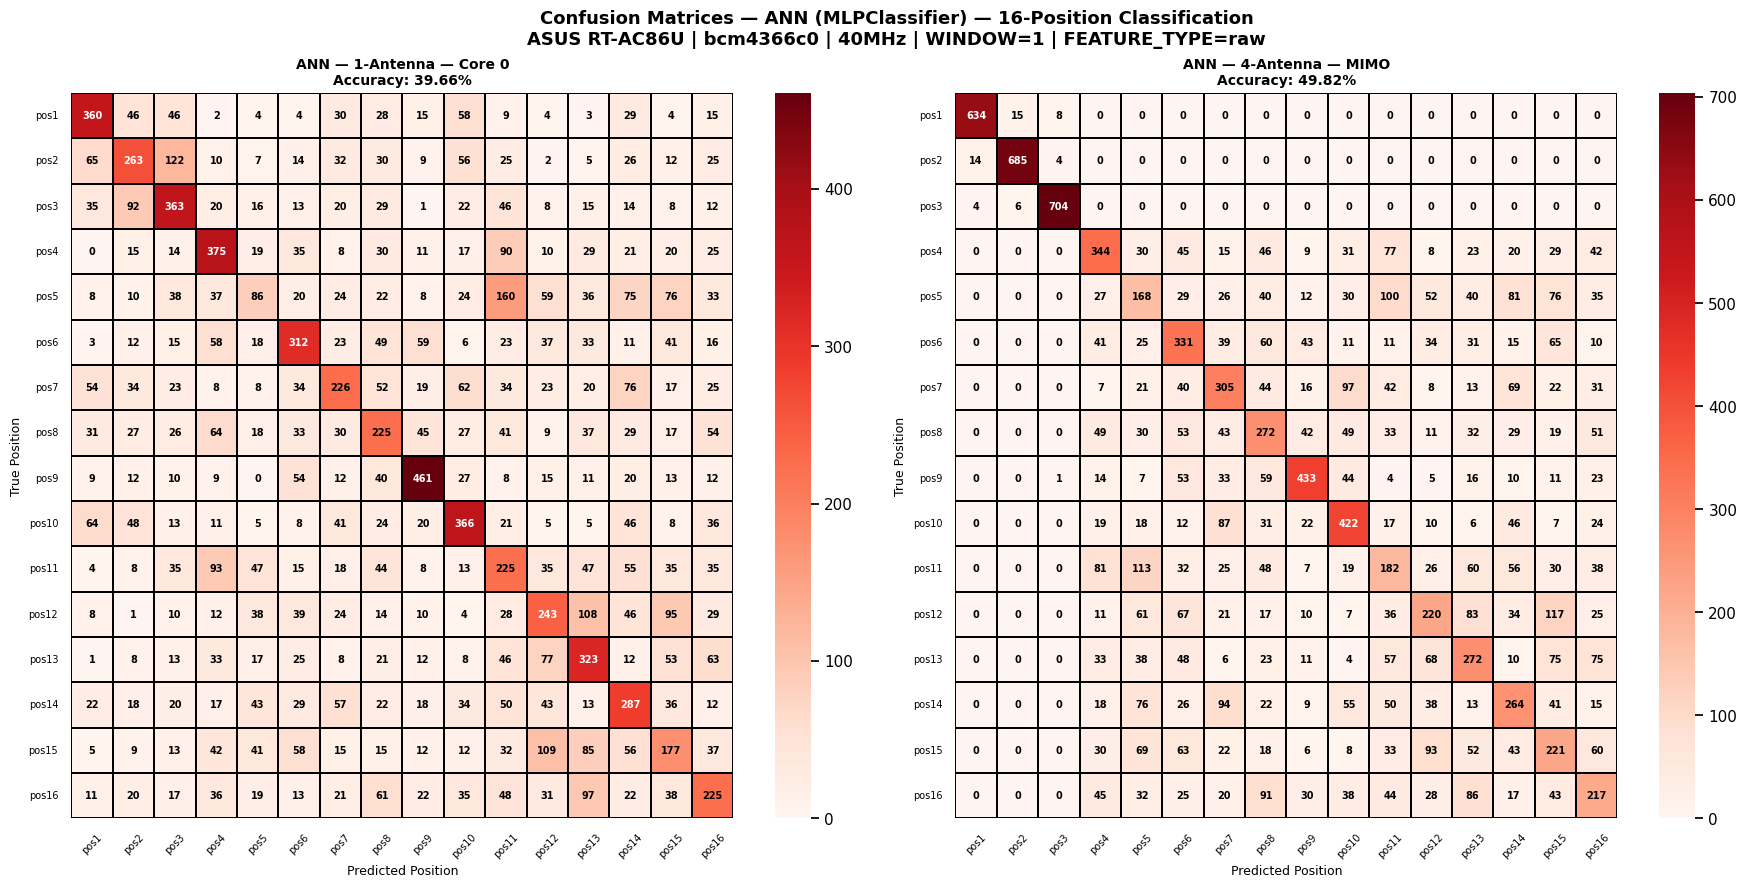

Saved: confusion_matrix_ann_raw.png / .eps


In [37]:
fig, axes = plt.subplots(1, n_strategies, figsize=(9 * n_strategies, 9))
if n_strategies == 1:
    axes = [axes]
fig.suptitle(
    f'Confusion Matrices — ANN (MLPClassifier) — 16-Position Classification\n'
    f'ASUS RT-AC86U | bcm4366c0 | 40MHz | WINDOW={WINDOW} | FEATURE_TYPE={FEATURE_TYPE}',
    fontsize=13, fontweight='bold'
)
for ax, (label, (acc, y_te, y_pred, _)) in zip(axes, results_ann.items()):
    cm = confusion_matrix(y_te, y_pred, labels=list(range(16)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                linewidths=0.3, linecolor='black',
                xticklabels=POS_LABELS, yticklabels=POS_LABELS,
                annot_kws={"size": 7, "fontweight": "bold"}, ax=ax)
    for text in ax.texts:
        val = int(text.get_text())
        text.set_color("white" if val > cm.max() / 2 else "black")
    ax.set_title(f'{label}\nAccuracy: {acc:.2f}%', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Position', fontsize=9)
    ax.set_ylabel('True Position', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
fname = f'confusion_matrix_ann_{FEATURE_TYPE}'
plt.savefig(os.path.join(OUTPUT_DIR, f'{fname}.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUTPUT_DIR, f'{fname}.eps'), format='eps', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {fname}.png / .eps")

### Confusion Matrices — RF

In [38]:
if ENABLE_RF:
    fig, axes = plt.subplots(1, n_strategies, figsize=(9 * n_strategies, 9))
    if n_strategies == 1:
        axes = [axes]
    fig.suptitle(
        f'Confusion Matrices — RF (RandomForest) — 16-Position Classification\n'
        f'ASUS RT-AC86U | bcm4366c0 | 40MHz | WINDOW={WINDOW} | FEATURE_TYPE={FEATURE_TYPE}',
        fontsize=13, fontweight='bold'
    )
    for ax, (label, (acc, y_te, y_pred, _)) in zip(axes, results_rf.items()):
        cm = confusion_matrix(y_te, y_pred, labels=list(range(16)))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    linewidths=0.3, linecolor='black',
                    xticklabels=POS_LABELS, yticklabels=POS_LABELS,
                    annot_kws={"size": 7, "fontweight": "bold"}, ax=ax)
        for text in ax.texts:
            val = int(text.get_text())
            text.set_color("white" if val > cm.max() / 2 else "black")
        ax.set_title(f'{label}\nAccuracy: {acc:.2f}%', fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted Position', fontsize=9)
        ax.set_ylabel('True Position', fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', rotation=0,  labelsize=7)
    plt.tight_layout()
    fname = f'confusion_matrix_rf_{FEATURE_TYPE}'
    plt.savefig(os.path.join(OUTPUT_DIR, f'{fname}.png'), dpi=150, bbox_inches='tight', facecolor='white')
    plt.savefig(os.path.join(OUTPUT_DIR, f'{fname}.eps'), format='eps', bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {fname}.png / .eps")
else:
    print("RF confusion matrix skipped (ENABLE_RF=False)")

RF confusion matrix skipped (ENABLE_RF=False)


### Per-Position Accuracy Grid — ANN and RF

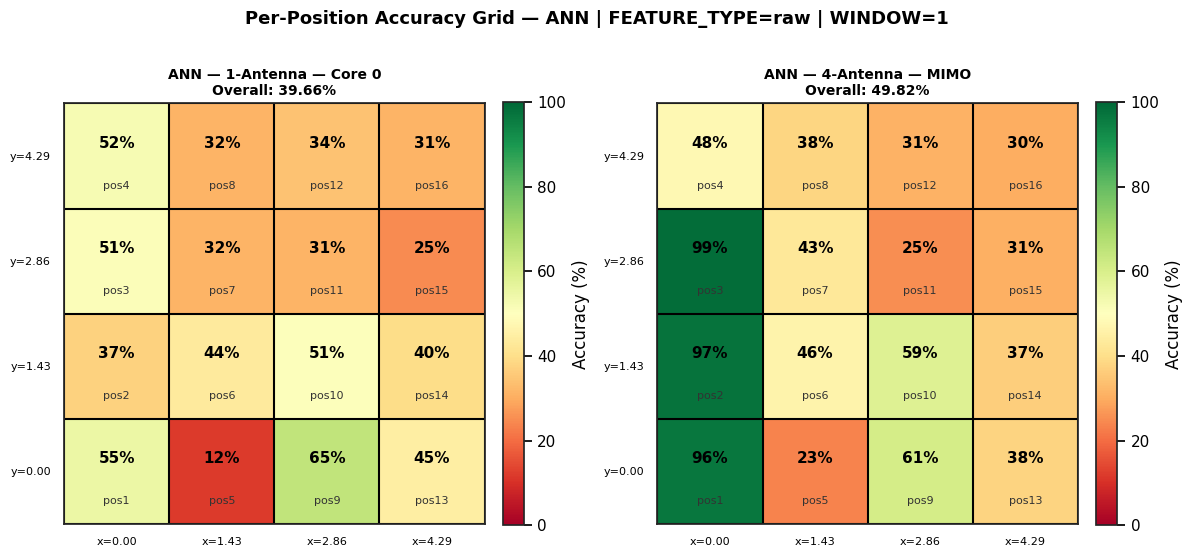

Saved: accuracy_grid_ann_raw.png / .eps
RF accuracy grid skipped (ENABLE_RF=False)


In [39]:
def plot_accuracy_grid(results, title, filename):
    """4×4 arena grid coloured by per-position accuracy. Green=high, Red=low."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, (label, (acc, y_te, y_pred, _)) in zip(axes, results.items()):
        grid = np.full((4, 4), np.nan)
        for i, pos in enumerate(POS_LABELS):
            mask = (y_te == i)
            if mask.sum() > 0:
                pa = accuracy_score(y_te[mask], y_pred[mask]) * 100
                r, c = POS_GRID[pos]
                grid[r, c] = pa
        im = ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=100, aspect='equal')
        for r in range(4):
            for c in range(4):
                v = grid[r, c]
                if not np.isnan(v):
                    ax.text(c, r - 0.12, f'{v:.0f}%',
                            ha='center', va='center',
                            fontsize=11, fontweight='bold', color='black')
                    pos_name = [p for p, (pr, pc) in POS_GRID.items() if pr == r and pc == c][0]
                    ax.text(c, r + 0.28, pos_name,
                            ha='center', va='center', fontsize=8, color='#333333')
        ax.set_xticks([0, 1, 2, 3])
        ax.set_yticks([0, 1, 2, 3])
        ax.set_xticklabels(['x=0.00', 'x=1.43', 'x=2.86', 'x=4.29'], fontsize=8)
        ax.set_yticklabels(['y=4.29', 'y=2.86', 'y=1.43', 'y=0.00'], fontsize=8)
        ax.set_xticks(np.arange(-0.5, 4, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
        ax.grid(which='minor', color='black', linewidth=1.5)
        ax.tick_params(which='minor', bottom=False, left=False)
        ax.set_title(f'{label}\nOverall: {acc:.2f}%', fontsize=10, fontweight='bold')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Accuracy (%)')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{filename}.png'), dpi=150, bbox_inches='tight', facecolor='white')
    plt.savefig(os.path.join(OUTPUT_DIR, f'{filename}.eps'), format='eps', bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {filename}.png / .eps")


plot_accuracy_grid(
    results_ann,
    f'Per-Position Accuracy Grid — ANN | FEATURE_TYPE={FEATURE_TYPE} | WINDOW={WINDOW}',
    f'accuracy_grid_ann_{FEATURE_TYPE}'
)

if ENABLE_RF:
    plot_accuracy_grid(
        results_rf,
        f'Per-Position Accuracy Grid — RF (RandomForest) | FEATURE_TYPE={FEATURE_TYPE} | WINDOW={WINDOW}',
        f'accuracy_grid_rf_{FEATURE_TYPE}'
    )
else:
    print("RF accuracy grid skipped (ENABLE_RF=False)")

### ANN Training Loss Curves

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


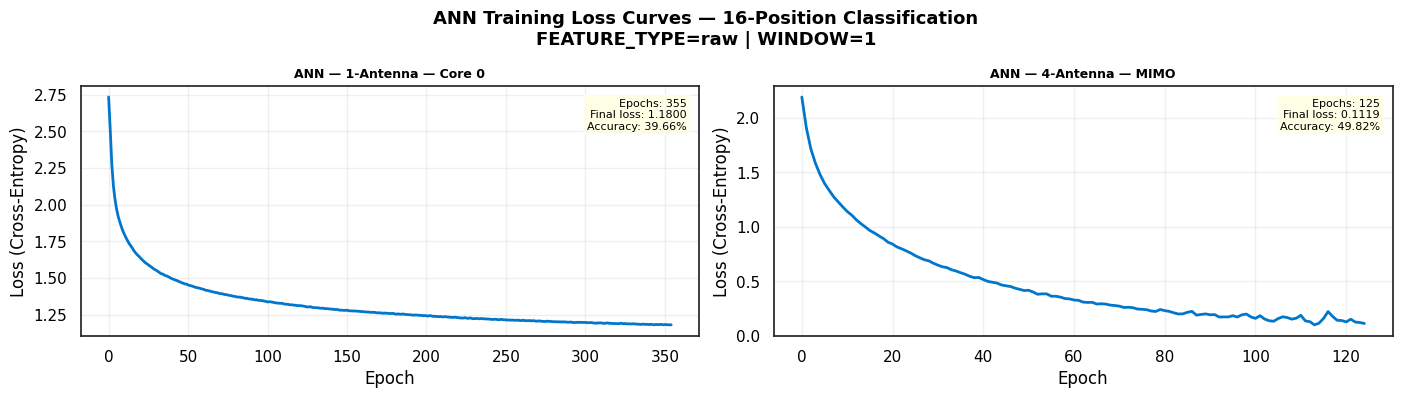

Saved: loss_curves_ann_raw.png / .eps


In [40]:
fig, axes = plt.subplots(1, n_strategies, figsize=(7 * n_strategies, 4))
if n_strategies == 1:
    axes = [axes]
fig.suptitle(
    f'ANN Training Loss Curves — 16-Position Classification\n'
    f'FEATURE_TYPE={FEATURE_TYPE} | WINDOW={WINDOW}',
    fontsize=13, fontweight='bold'
)
for ax, (label, (acc, _, _, model)) in zip(axes, results_ann.items()):
    ax.plot(model.loss_curve_, color='#0077cc', linewidth=2)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (Cross-Entropy)')
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.95,
            f'Epochs: {model.n_iter_}\nFinal loss: {model.loss_:.4f}\nAccuracy: {acc:.2f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
fname = f'loss_curves_ann_{FEATURE_TYPE}'
plt.savefig(os.path.join(OUTPUT_DIR, f'{fname}.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUTPUT_DIR, f'{fname}.eps'), format='eps', bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {fname}.png / .eps")

### Amplitude² Profiles Per Antenna Core

Shows mean amp² vs subcarrier index — one line per position, one panel per core.  
Well-separated lines = that core carries a strong location fingerprint.  
*(Only plotted for `FEATURE_TYPE='raw'` — no per-subcarrier data in stats mode.)*

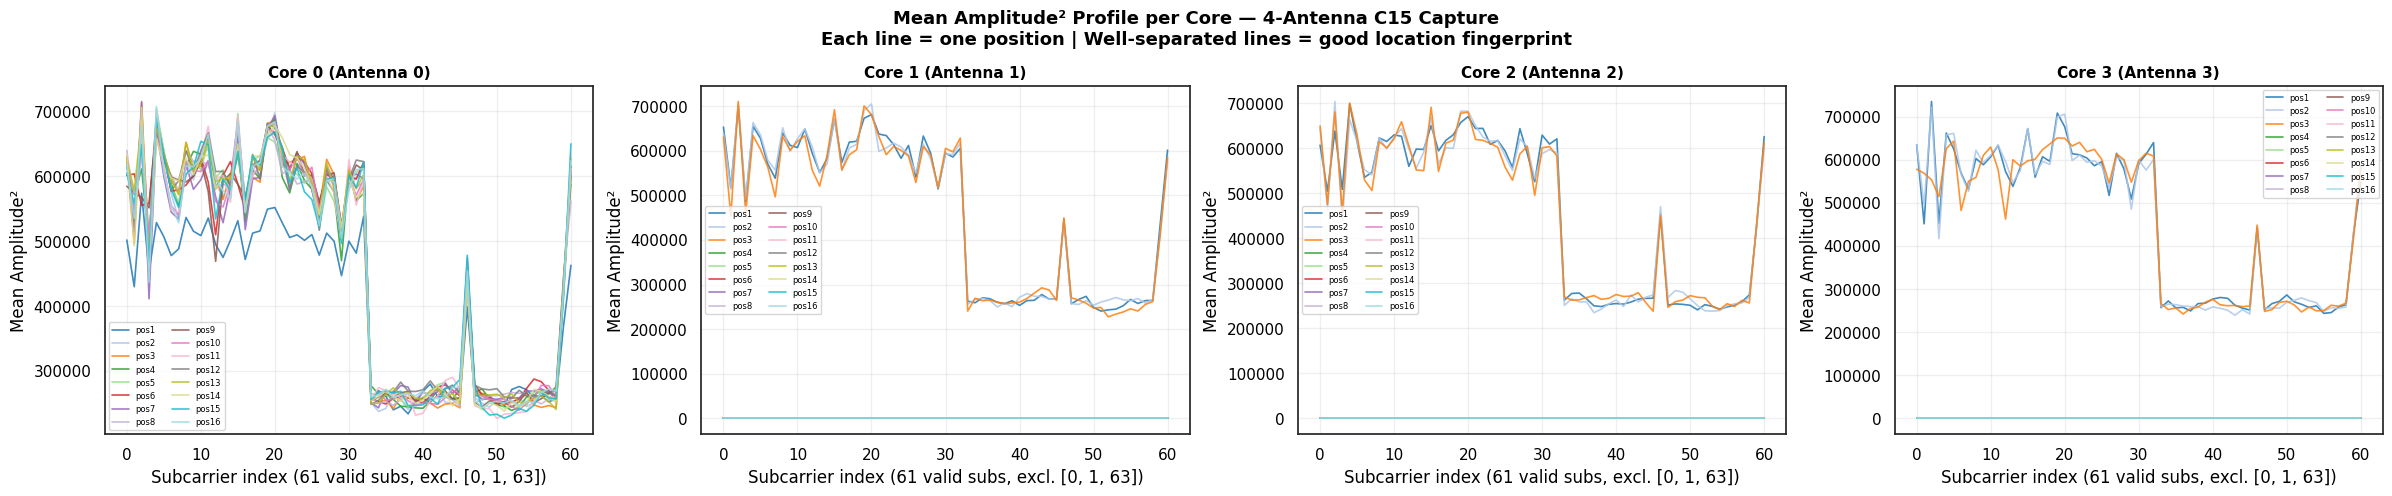

Saved: amplitude_profiles.png


In [41]:
if FEATURE_TYPE == 'raw':
    fig, axes_amp = plt.subplots(1, 4, figsize=(24, 5))
    fig.suptitle(
        'Mean Amplitude² Profile per Core — 4-Antenna C15 Capture\n'
        'Each line = one position | Well-separated lines = good location fingerprint',
        fontsize=13, fontweight='bold'
    )
    colors_amp = plt.cm.tab20(np.linspace(0, 1, 16))
    for cid, ax in enumerate(axes_amp):
        cols = [c for c in df_4ant.columns if c.startswith(f'amp_sq_c{cid}_')]
        for i, pos in enumerate(POS_LABELS):
            sub      = df_4ant[df_4ant['position'] == pos]
            mean_amp = sub[cols].mean(axis=0).values
            ax.plot(range(N_VALID_SUBS), mean_amp, label=pos,
                    color=colors_amp[i], linewidth=1.2, alpha=0.85)
        ax.set_title(f'Core {cid} (Antenna {cid})', fontsize=11, fontweight='bold')
        ax.set_xlabel(f'Subcarrier index ({N_VALID_SUBS} valid subs, excl. {REMOVE_SUBS})')
        ax.set_ylabel('Mean Amplitude²')
        ax.legend(fontsize=6, ncol=2)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'amplitude_profiles.png'), dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: amplitude_profiles.png")
else:
    print("Amplitude profile plot skipped — not applicable for FEATURE_TYPE='stats'")

## Step 12: Final Results Summary

In [42]:
print("\n" + "=" * 70)
print("FINAL RESULTS SUMMARY — 16-Position Classification")
print("=" * 70)
print(f"  Hardware     : ASUS RT-AC86U | bcm4366c0 | 40MHz | WINDOW={WINDOW}")
print(f"  FEATURE_TYPE : {FEATURE_TYPE}")
print(f"  ENABLE_MRC   : {ENABLE_MRC}")
print(f"  ENABLE_RF    : {ENABLE_RF}")
print(f"  Features     : 1-Ant={len(FEAT_1ANT)}  MRC={len(FEAT_MRC)}  4-Ant={len(FEAT_4ANT)}")
print(f"  Random chance baseline (16 classes) : {100/16:.2f}%")
print(f"  {'─' * 65}")
print(f"  {'Strategy':<35} {'ANN':>12}  {'RF':>12}")
print(f"  {'─' * 65}")

strategies = ['1-Antenna — Core 0', '4-Antenna — MRC', '4-Antenna — MIMO'] if ENABLE_MRC \
             else ['1-Antenna — Core 0', '4-Antenna — MIMO']

for s in strategies:
    ann_acc = results_ann.get(f'ANN — {s}', (None,))[0]
    rf_acc  = results_rf.get( f'RF  — {s}', (None,))[0] if ENABLE_RF else None
    ann_str = f'{ann_acc:.2f}%' if ann_acc is not None else 'N/A'
    rf_str  = f'{rf_acc:.2f}%'  if rf_acc  is not None else 'N/A (skipped)'
    print(f"  {s:<35} {ann_str:>12}  {rf_str:>12}")

print("=" * 70)
print(f"\nOutput files saved to: {OUTPUT_DIR}")
print(f"  confusion_matrix_ann_{FEATURE_TYPE}.png/.eps")
print(f"  accuracy_grid_ann_{FEATURE_TYPE}.png/.eps")
print(f"  loss_curves_ann_{FEATURE_TYPE}.png/.eps")
if ENABLE_RF:
    print(f"  confusion_matrix_rf_{FEATURE_TYPE}.png/.eps")
    print(f"  accuracy_grid_rf_{FEATURE_TYPE}.png/.eps")
if FEATURE_TYPE == 'raw':
    print("  amplitude_profiles.png")


FINAL RESULTS SUMMARY — 16-Position Classification
  Hardware     : ASUS RT-AC86U | bcm4366c0 | 40MHz | WINDOW=1
  FEATURE_TYPE : raw
  ENABLE_MRC   : False
  ENABLE_RF    : False
  Features     : 1-Ant=61  MRC=61  4-Ant=244
  Random chance baseline (16 classes) : 6.25%
  ─────────────────────────────────────────────────────────────────
  Strategy                                     ANN            RF
  ─────────────────────────────────────────────────────────────────
  1-Antenna — Core 0                        39.66%  N/A (skipped)
  4-Antenna — MIMO                          49.82%  N/A (skipped)

Output files saved to: /home/azbil-new/localization
  confusion_matrix_ann_raw.png/.eps
  accuracy_grid_ann_raw.png/.eps
  loss_curves_ann_raw.png/.eps
  amplitude_profiles.png
